In [ ]:
# LAB 4

In [42]:
pip install opensignalsreader

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [44]:
# Import OpenSignalsReader
from opensignalsreader import OpenSignalsReader


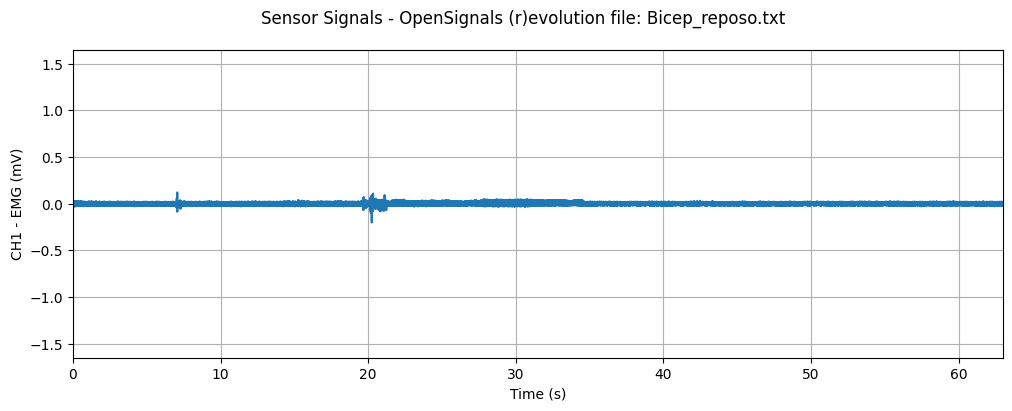

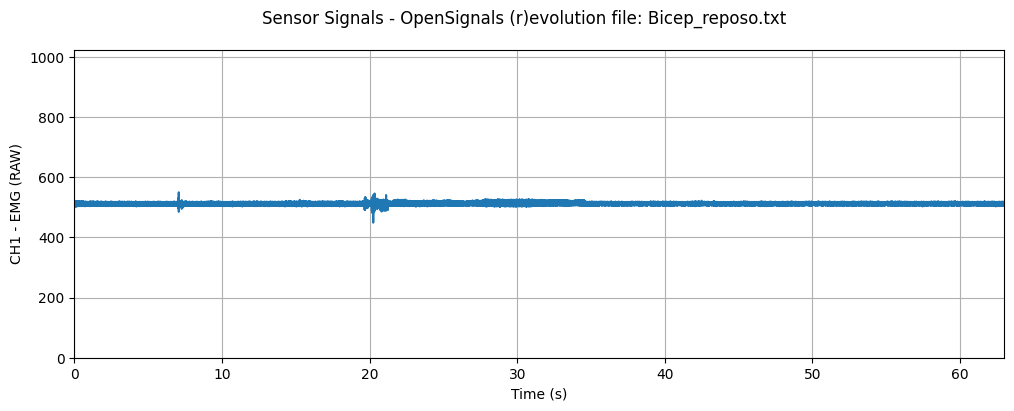

In [45]:
# Read OpenSignals file and plot all signals
acq = OpenSignalsReader('Bicep_reposo.txt', show=True)

# Read OpenSignals file and plot all raw signals.
acq = OpenSignalsReader('Bicep_reposo.txt', show=True, raw=True)



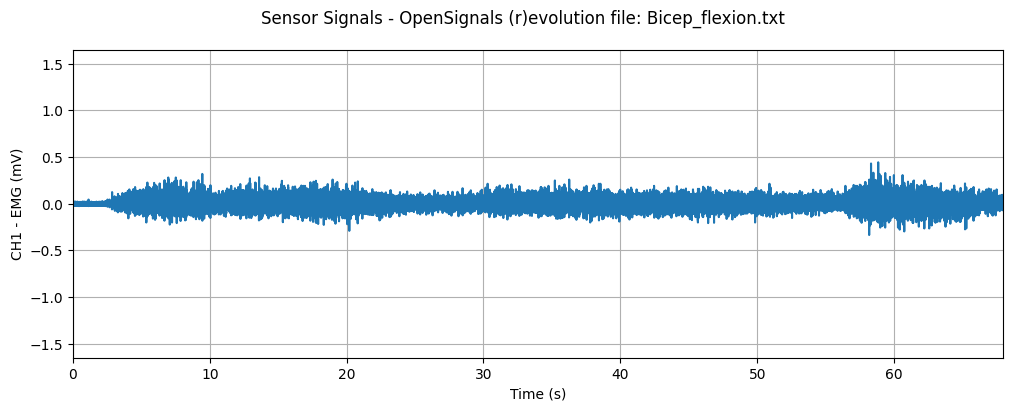

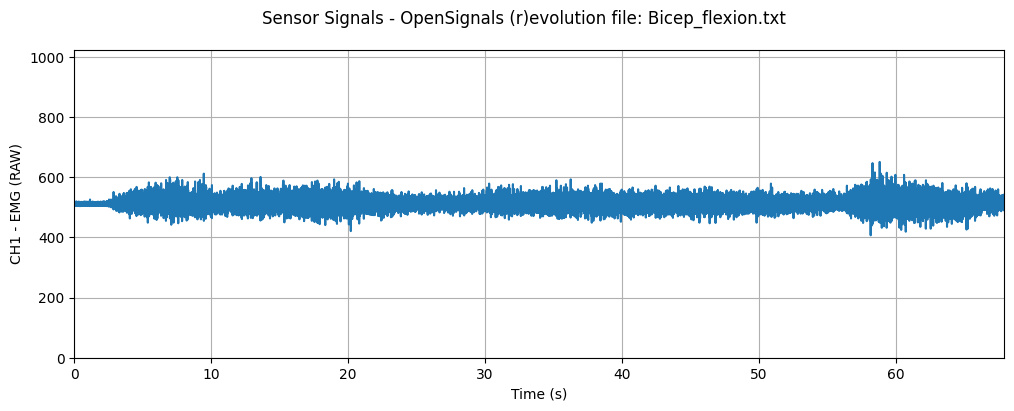

In [46]:
# Read OpenSignals file and plot all signals
acq = OpenSignalsReader('Bicep_flexion.txt', show=True)

# Read OpenSignals file and plot all raw signals.
acq = OpenSignalsReader('Bicep_flexion.txt', show=True, raw=True)

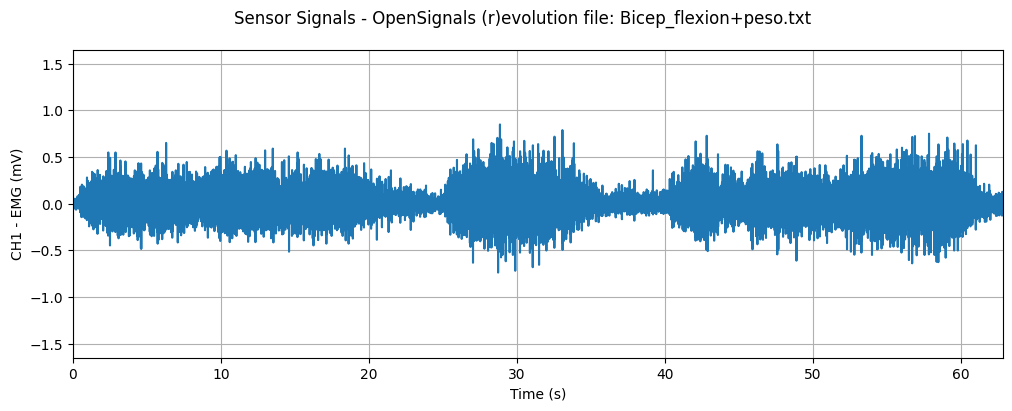

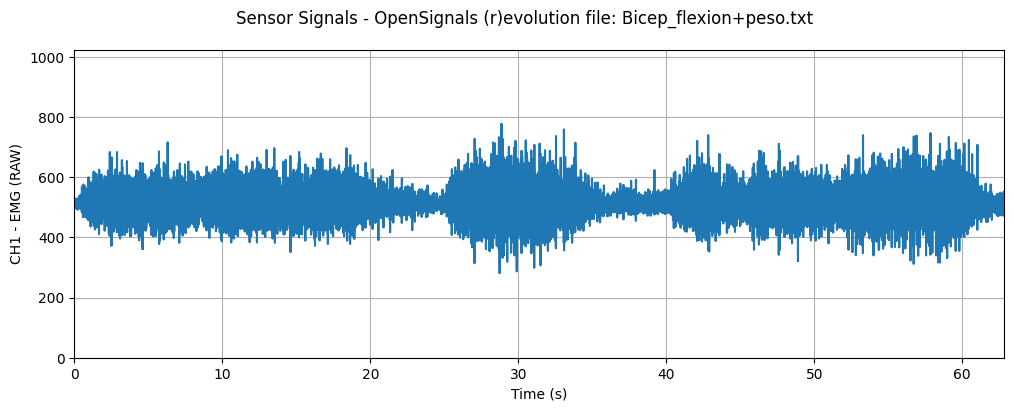

In [47]:
# Read OpenSignals file and plot all signals
acq = OpenSignalsReader('Bicep_flexion+peso.txt', show=True)

# Read OpenSignals file and plot all raw signals.
acq = OpenSignalsReader('Bicep_flexion+peso.txt', show=True, raw=True)

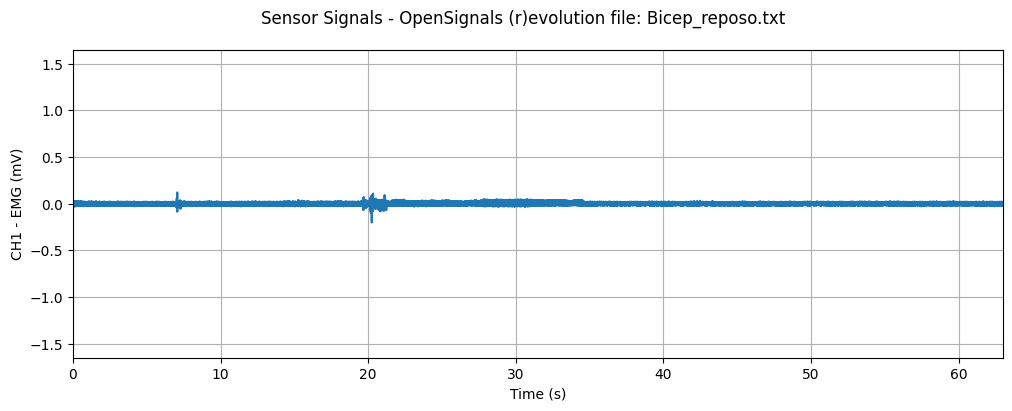

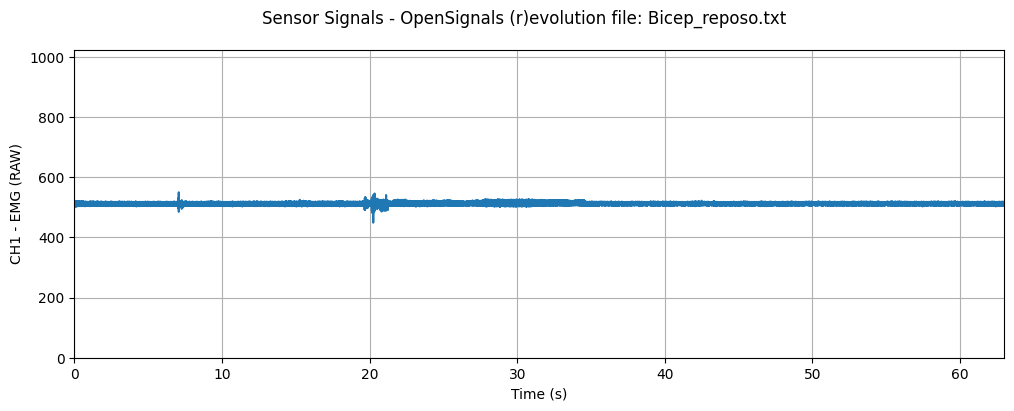

In [49]:
# Read OpenSignals file and plot all signals
acq = OpenSignalsReader('Bicep_reposo.txt', show=True)

# Read OpenSignals file and plot all raw signals.
acq = OpenSignalsReader('Bicep_reposo.txt', show=True, raw=True)

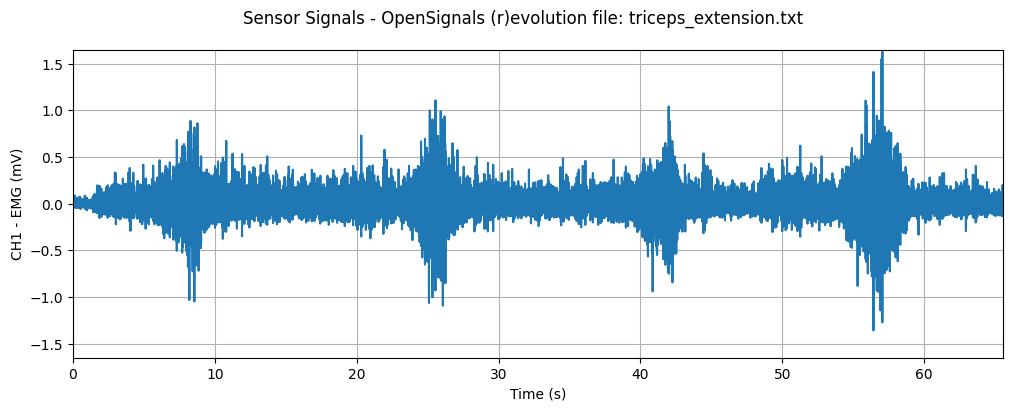

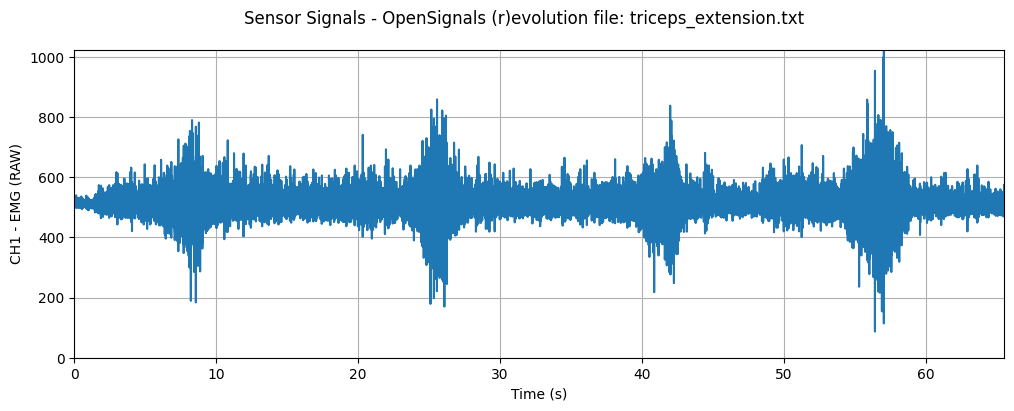

In [50]:
# Read OpenSignals file and plot all signals
acq = OpenSignalsReader('triceps_extension.txt', show=True)

# Read OpenSignals file and plot all raw signals.
acq = OpenSignalsReader('triceps_extension.txt', show=True, raw=True)

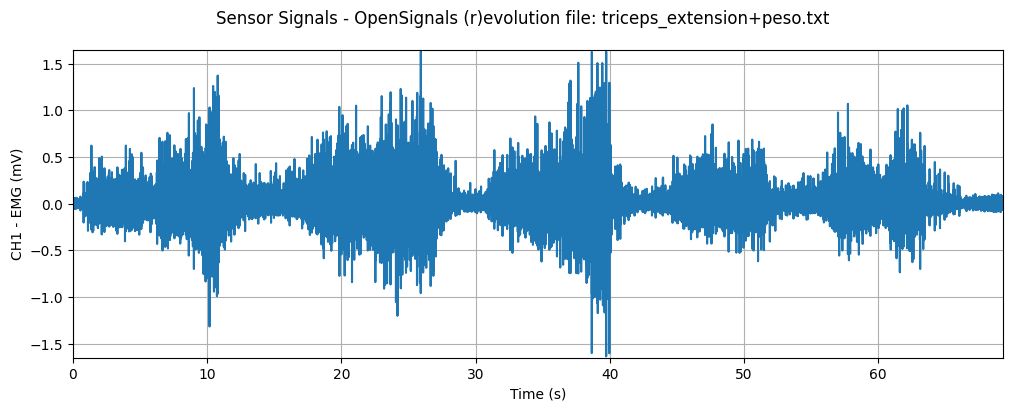

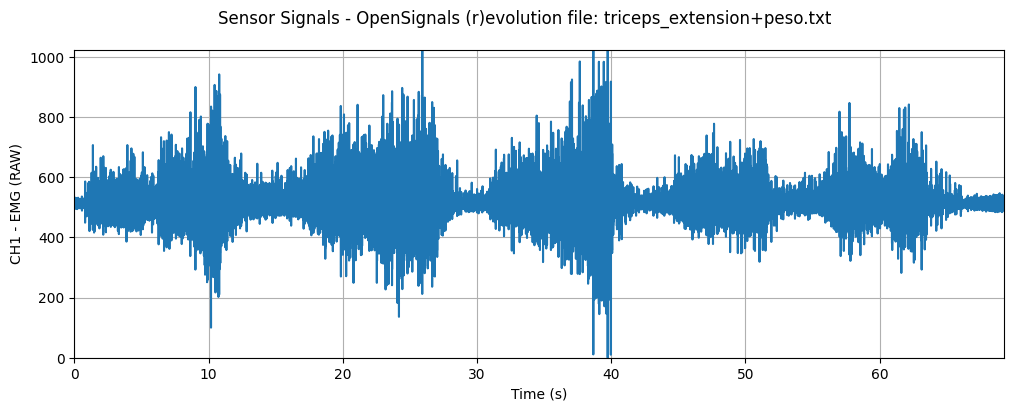

In [51]:
# Read OpenSignals file and plot all signals
acq_bicep_reposo = OpenSignalsReader('triceps_extension+peso.txt', show=True)

# Read OpenSignals file and plot all raw signals.
acq_bicep_reposo = OpenSignalsReader('triceps_extension+peso.txt', show=True, raw=True)

### Cálculo y visualización de la FFT (Transformada Rápida de Fourier)


=== Procesando: Bicep_reposo.txt ===


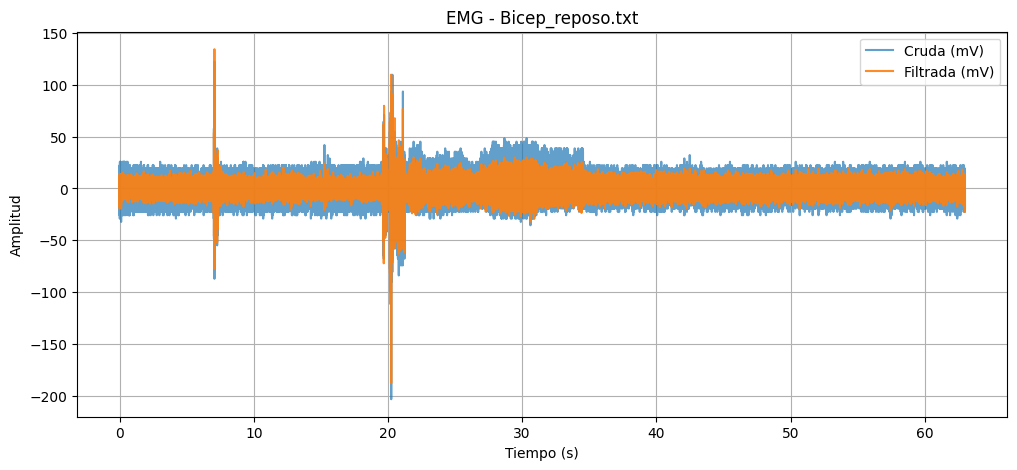

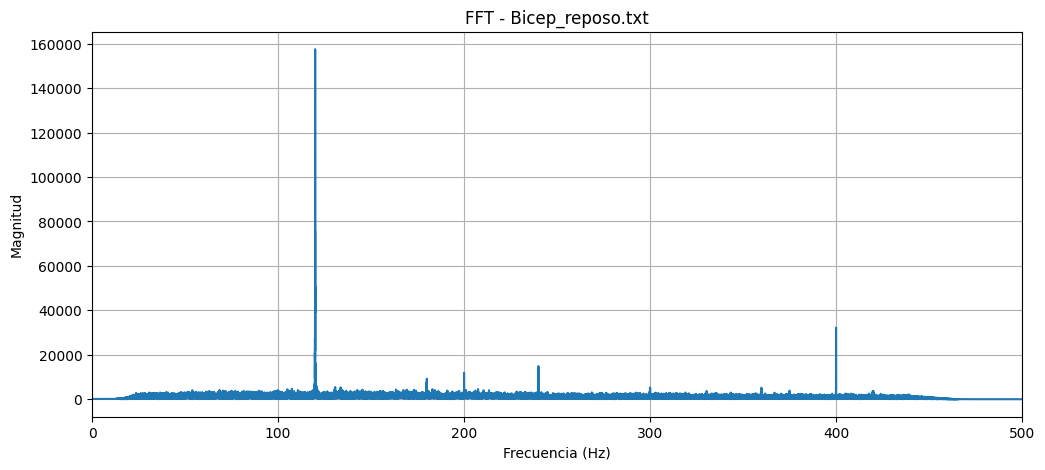


=== Procesando: Bicep_flexion.txt ===


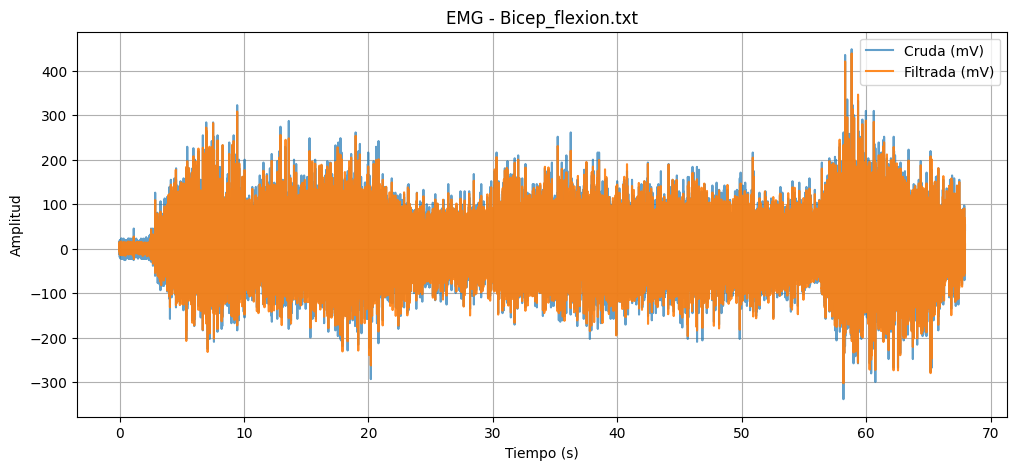

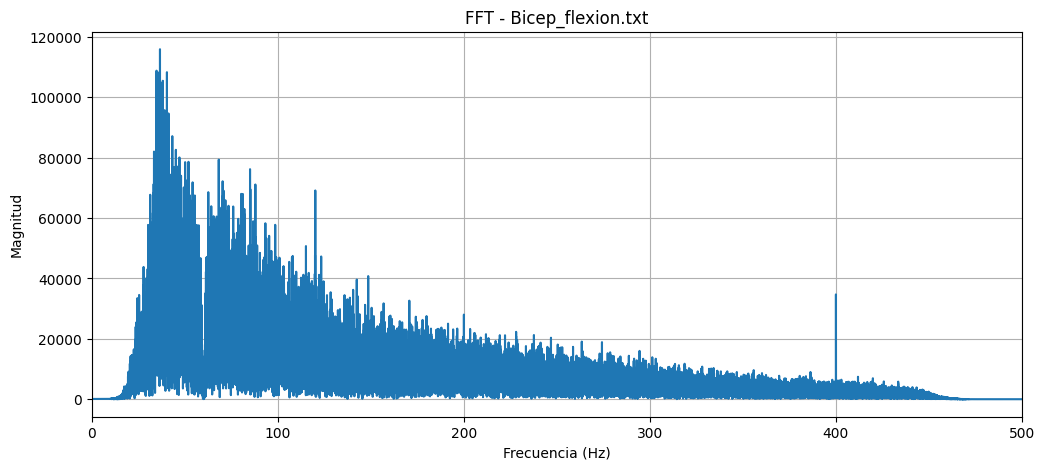


=== Procesando: Bicep_flexion+peso.txt ===


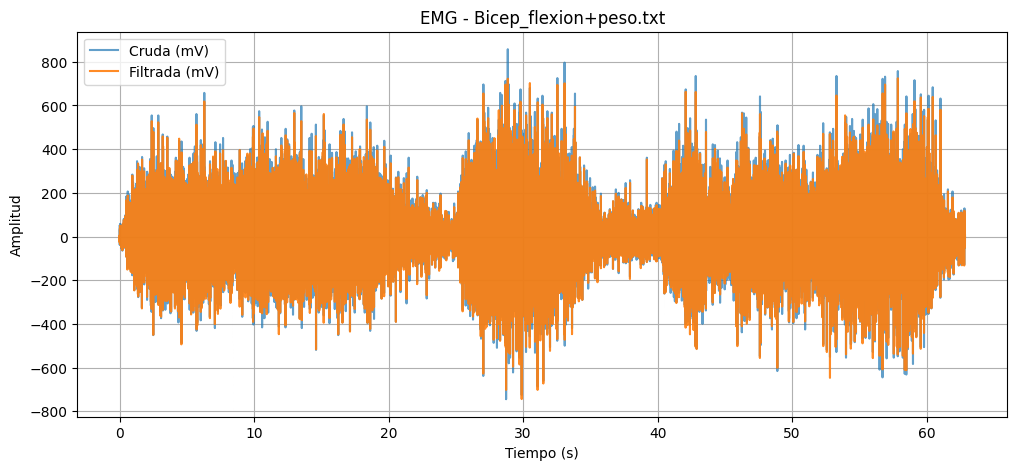

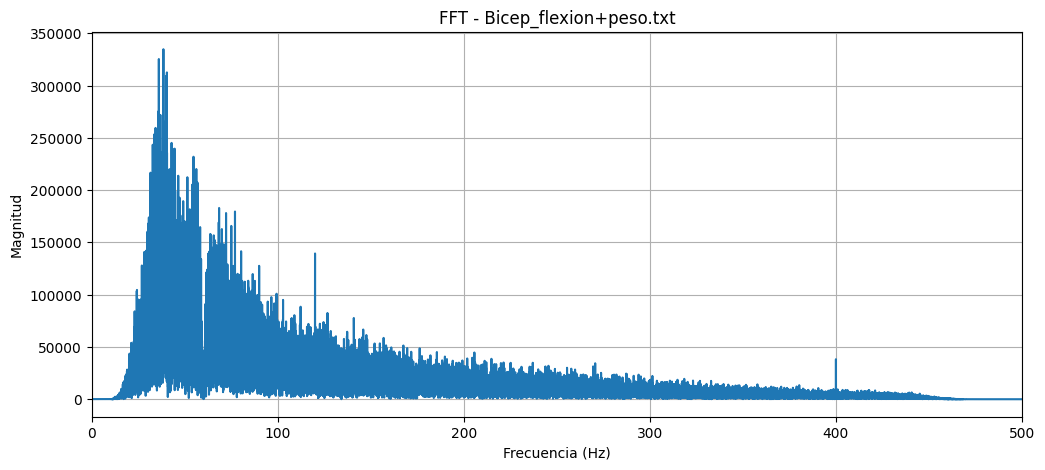


=== Procesando: triceps_extension.txt ===


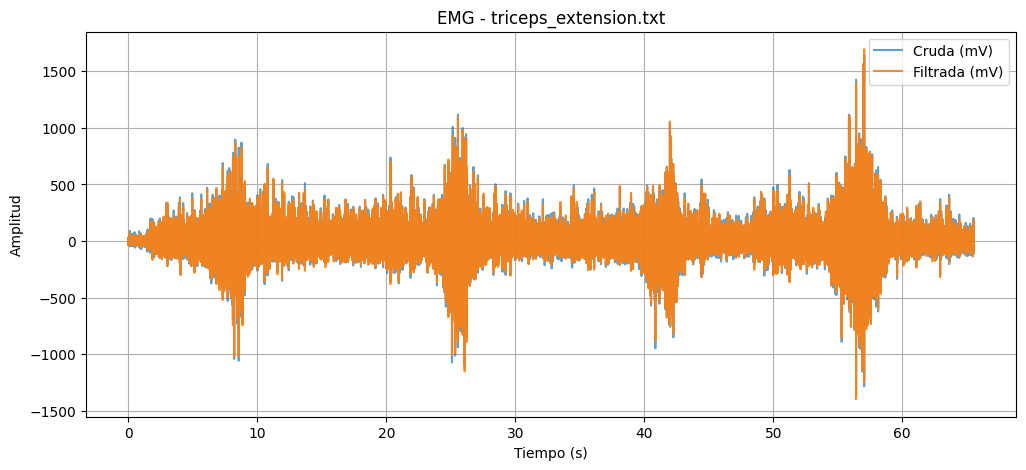

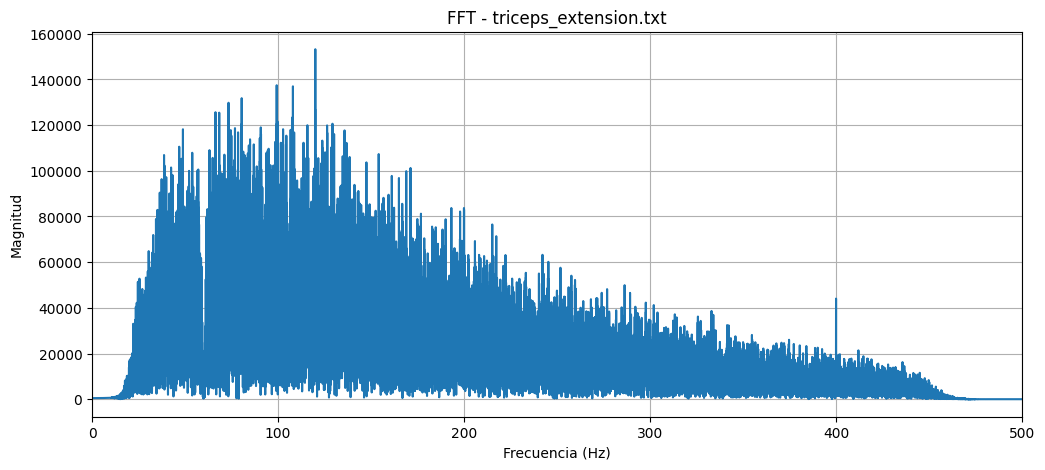


=== Procesando: triceps_extension+peso.txt ===


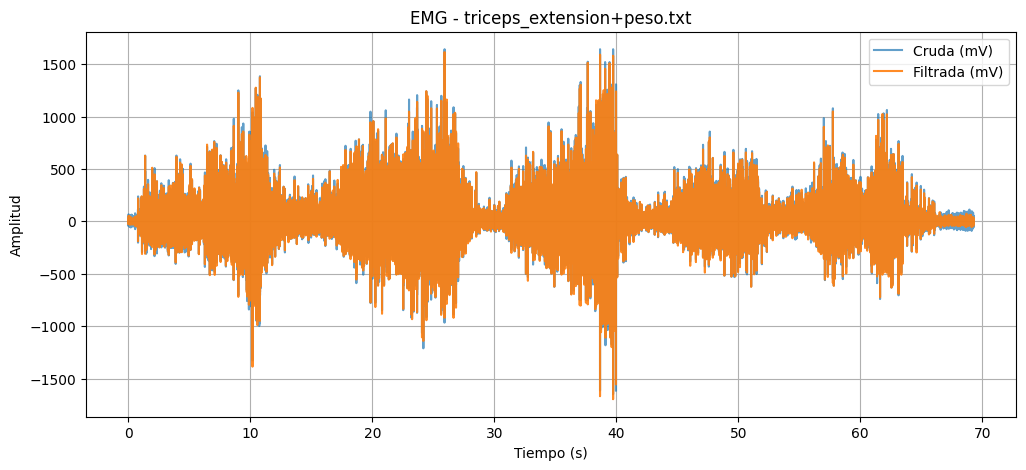

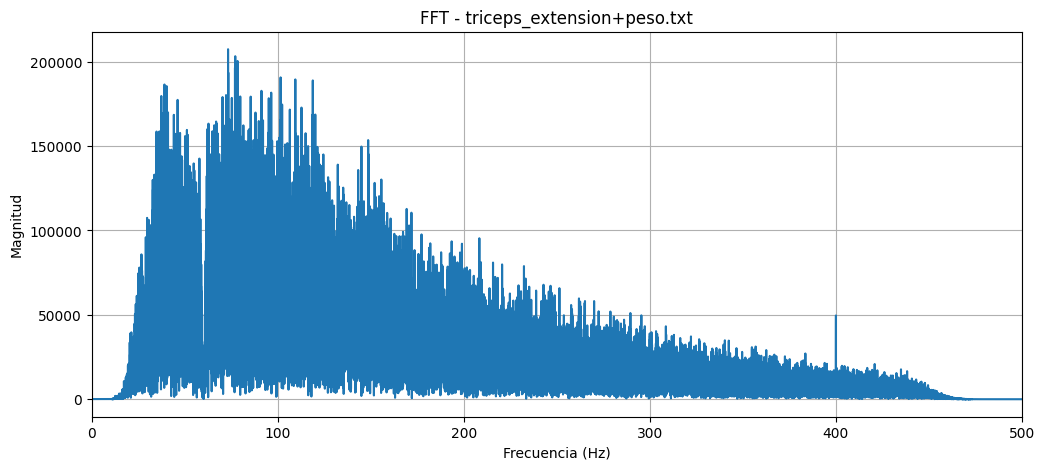


=== Procesando: triceps_reposo.txt ===


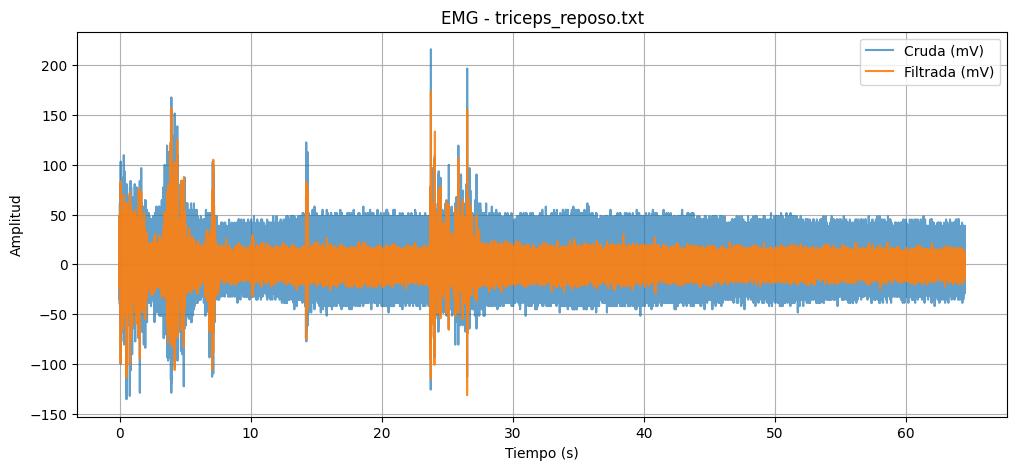

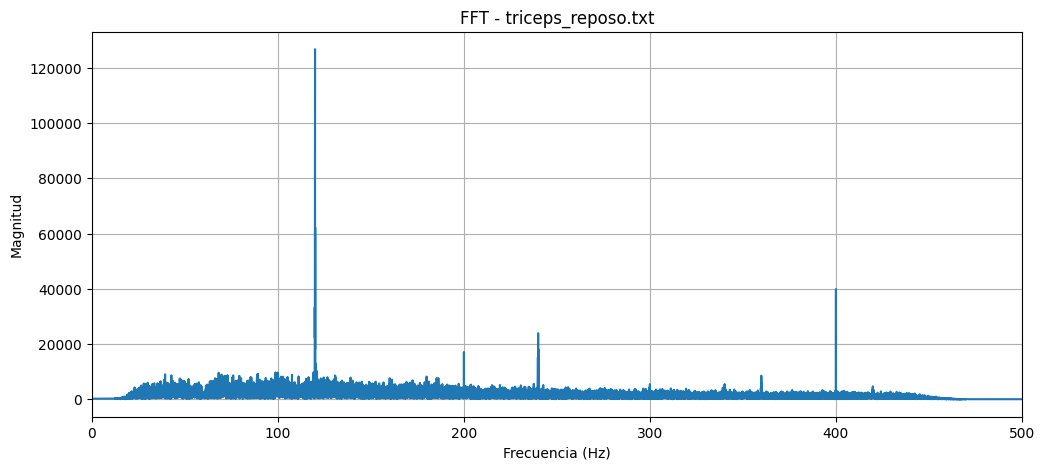

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from scipy.fft import fft, fftfreq

# Lista de archivos
archivos = [
    'Bicep_reposo.txt',
    'Bicep_flexion.txt',
    'Bicep_flexion+peso.txt',
    'triceps_extension.txt',
    'triceps_extension+peso.txt',
    'triceps_reposo.txt'
]

# Parámetros fijos
fs = 1000               # Hz, frecuencia de muestreo
Vcc = 3.3               # Voltaje de referencia
resolution = 10         # bits
notch_freq = 60         # Hz
quality = 30            # Factor de calidad del notch
band_low = 20           # Hz
band_high = 450         # Hz

nyquist = fs / 2.0

# Diseño de filtros
b_notch, a_notch = iirnotch(notch_freq, quality, fs)
b_band, a_band = butter(4, [band_low/nyquist, band_high/nyquist], btype='band')

# Procesar cada archivo
for file_name in archivos:
    print(f"\n=== Procesando: {file_name} ===")

    # 1. Cargar datos
    try:
        data = np.loadtxt(file_name, comments='#')
    except FileNotFoundError:
        print(f"  Archivo no encontrado: {file_name}. Saltando...")
        continue

    # Extraer la última columna
    signal = data[:, -1]

    # Vector de tiempo
    time = np.arange(len(signal)) / fs

    # 2. Convertir cuentas a mV
    signal_mv = (signal / (2**resolution) - 0.5) * Vcc * 1000

    # 3. Aplicar filtro notch
    signal_notch = filtfilt(b_notch, a_notch, signal_mv)

    # 4. Aplicar filtro pasa banda
    signal_filtered = filtfilt(b_band, a_band, signal_notch)

    # 5. FFT de la señal filtrada
    N = len(signal_filtered)
    yf = fft(signal_filtered)
    xf = fftfreq(N, 1/fs)
    xf = xf[:N//2]
    yf = np.abs(yf[:N//2])

    # 6. Gráfica temporal (cruda vs filtrada)
    plt.figure(figsize=(12, 5))
    plt.plot(time, signal_mv, label='Cruda (mV)', alpha=0.7)
    plt.plot(time, signal_filtered, label='Filtrada (mV)', alpha=0.9)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.title(f'EMG - {file_name}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 7. Gráfica FFT (espectro)
    plt.figure(figsize=(12, 5))
    plt.plot(xf, yf)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.title(f'FFT - {file_name}')
    plt.xlim(0, 500)
    plt.grid(True)
    plt.show()